# Mental Health NLP: Modeling Mental Health Dynamics from Social Media Text

In this project, we explore how mental health signals can be extracted and modeled from social media text, focusing on patterns over time rather than static classification.

## Overview

- **Motivation:** We move beyond treating mental health as a fixed label, acknowledging that real-world signals are dynamic and evolve over time.  
- **Objective:** We aim to capture temporal patterns, user-level behavior, and early warning signs from text data.  
- **Approach:** We begin with data understanding and baseline models, then progress toward advanced and temporal modeling techniques.

## Workflow

- **Data Exploration:** We analyze dataset structure, distributions, and potential biases to assess data quality.  
- **Preprocessing:** We clean and normalize text, and prepare both post-level and user-level representations.  
- **Baseline Models:** We train simple models (e.g., TF-IDF + Logistic Regression) to establish reference performance.  
- **Advanced Models:** We apply transformer-based models to capture deeper semantic patterns and improve results.  
- **Temporal Modeling:** We model sequences of posts to identify changes in mental health over time.  
- **Early Signals:** We investigate linguistic and behavioral patterns that may indicate early risk.

## Key Idea

- **Shift in Perspective:** We transition from static classification → dynamic, time-aware mental health modeling.  

## 0. Load Data

We begin by loading the dataset and inspecting its structure. This step ensures that all columns are correctly parsed and the dataset is ready for preprocessing.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

In [2]:
warnings.filterwarnings("ignore")

# Load the raw dataset
DATA_PATH = "Mental-Health-Twitter.csv"
df_raw = pd.read_csv(DATA_PATH)

print("Dataset shape:", df_raw.shape)
display(df_raw.head())

Dataset shape: (20000, 11)


,Unnamed: 0,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1
3,3,637696421077123073,Sat Aug 29 18:40:49 +0000 2015,RT @SewHQ: #Retro bears make perfect gifts and...,1013187241,84,211,251,837,2,1
4,4,637696327485366272,Sat Aug 29 18:40:26 +0000 2015,It’s hard to say whether packing lists are mak...,1013187241,84,211,251,837,1,1


In [3]:
# Inspect column types and missing values
print(df_raw.info())
print("\nMissing values:\n")
print(df_raw.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    20000 non-null  int64 
 1   post_id       20000 non-null  int64 
 2   post_created  20000 non-null  object
 3   post_text     20000 non-null  object
 4   user_id       20000 non-null  int64 
 5   followers     20000 non-null  int64 
 6   friends       20000 non-null  int64 
 7   favourites    20000 non-null  int64 
 8   statuses      20000 non-null  int64 
 9   retweets      20000 non-null  int64 
 10  label         20000 non-null  int64 
dtypes: int64(9), object(2)
memory usage: 1.7+ MB
None

Missing values:

Unnamed: 0      0
post_id         0
post_created    0
post_text       0
user_id         0
followers       0
friends         0
favourites      0
statuses        0
retweets        0
label           0
dtype: int64


## 1. Data Preparation

This section prepares the dataset for analysis and modeling. It includes removing unnecessary columns, cleaning text data, and organizing posts into user-level timelines.


In [4]:
# Create a clean working copy
df = df_raw.copy()

# Remove columns that are not needed for NLP or timeline modeling
df = df.drop(columns=[
    "Unnamed: 0",
    "followers",
    "friends",
    "favourites",
    "statuses",
    "retweets"
], errors="ignore")

# Keep the original label separately for later evaluation only
labels = df["label"].copy()
df = df.drop(columns=["label"])

print("Remaining columns:")
print(df.columns.tolist())

print("\nLabel distribution:")
display(labels.value_counts())

Remaining columns:
['post_id', 'post_created', 'post_text', 'user_id']

Label distribution:


,count
label,
1,10000
0,10000


In [5]:
# Convert timestamps for proper chronological ordering
df["post_created"] = pd.to_datetime(
    df["post_created"],
    format="%a %b %d %H:%M:%S +0000 %Y",
    utc=True,
    errors="coerce"
)

print("Date range:", df["post_created"].min(), "to", df["post_created"].max())

Date range: 2009-08-26 13:19:08+00:00 to 2017-01-12 08:13:53+00:00


In [6]:
# Clean social media text by normalizing common noisy patterns
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = re.sub(r"http\S+|www\.\S+", "[URL]", text)
    text = re.sub(r"^RT @\w+:", "", text).strip()
    text = re.sub(r"@\w+", "@USER", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["post_text_clean"] = df["post_text"].apply(clean_text)

display(df[["post_text", "post_text_clean"]].head())

,post_text,post_text_clean
0,It's just over 2 years since I was diagnosed w...,It's just over 2 years since I was diagnosed w...
1,"It's Sunday, I need a break, so I'm planning t...","It's Sunday, I need a break, so I'm planning t..."
2,Awake but tired. I need to sleep but my brain ...,Awake but tired. I need to sleep but my brain ...
3,RT @SewHQ: #Retro bears make perfect gifts and...,#Retro bears make perfect gifts and are great ...
4,It’s hard to say whether packing lists are mak...,It’s hard to say whether packing lists are mak...


In [7]:
# Add simple text-level features
df["word_count"] = df["post_text_clean"].apply(lambda x: len(str(x).split()))
df["char_count"] = df["post_text_clean"].apply(lambda x: len(str(x)))

display(df[["word_count", "char_count"]].describe().round(2))

,word_count,char_count
count,20000.00,20000.00
mean,12.15,67.97
std,6.76,35.72
min,1.00,4.00
25%,6.00,37.00
50%,11.00,63.00
75%,17.00,100.00
max,34.00,159.00


In [8]:
# Sort posts by user and time to prepare timeline-based analysis
timeline_df = df.sort_values(["user_id", "post_created"]).copy()
timeline_df["label"] = df_raw.loc[timeline_df.index, "label"].values

# Position of each post within a user's timeline
timeline_df["timeline_position"] = timeline_df.groupby("user_id").cumcount()

# Number of posts per user
timeline_df["post_count"] = timeline_df.groupby("user_id")["post_id"].transform("count")

# Relative position in the timeline
timeline_df["timeline_fraction"] = (
    timeline_df["timeline_position"] / (timeline_df["post_count"] - 1).replace(0, 1)
)

# Keep only the final columns
timeline_df = timeline_df[
    [
        "post_id",
        "post_created",
        "post_text",
        "user_id",
        "label",
        "post_text_clean",
        "word_count",
        "char_count",
        "timeline_position",
        "post_count",
        "timeline_fraction",
    ]
]

display(timeline_df.head())

,post_id,post_created,post_text,user_id,label,post_text_clean,word_count,char_count,timeline_position,post_count,timeline_fraction
7705,701184305071054849,2016-02-20 23:19:00+00:00,Bf said he heard my phone notifications going ...,14724376,1,Bf said he heard my phone notifications going ...,26,135,0,341,0.000000
7704,701235946566635521,2016-02-21 02:44:12+00:00,I have watched so many terrible romantic comed...,14724376,1,I have watched so many terrible romantic comed...,16,89,1,341,0.002941
7703,701238259603677184,2016-02-21 02:53:24+00:00,Maid in Manhattan still gives me the most conf...,14724376,1,Maid in Manhattan still gives me the most conf...,13,74,2,341,0.005882
7702,701239534462308352,2016-02-21 02:58:28+00:00,"I know that's not 2002 Ralph but just DANG, OK",14724376,1,"I know that's not 2002 Ralph but just DANG, OK",10,46,3,341,0.008824
7701,701460861534208000,2016-02-21 17:37:56+00:00,@threehares THAT TONGUE THO 😝,14724376,1,@USER THAT TONGUE THO 😝,5,23,4,341,0.011765


In [9]:
# Final quick check
print("Prepared dataset shape:", timeline_df.shape)
print("Number of users:", timeline_df["user_id"].nunique())
print("Average posts per user:", round(timeline_df.groupby("user_id").size().mean(), 2))
print("\nFinal columns:")
print(timeline_df.columns.tolist())

Prepared dataset shape: (20000, 11)
Number of users: 72
Average posts per user: 277.78

Final columns:
['post_id', 'post_created', 'post_text', 'user_id', 'label', 'post_text_clean', 'word_count', 'char_count', 'timeline_position', 'post_count', 'timeline_fraction']


### Comments on Results

The dataset contains 20,000 posts from 72 users, with an average of approximately 278 posts per user. This indicates a relatively small number of users, but with dense posting activity over time.

- **Data Structure Insight:** The limited number of users combined with high posting frequency makes the dataset more suitable for longitudinal and user-level analysis rather than treating each post as an independent sample.  
- **Modeling Implication:** Instead of focusing solely on post-level classification, we prioritize modeling temporal dynamics and behavioral patterns across user timelines.  

At this stage, the dataset has been cleaned, standardized, and reorganized into user timelines.

- **Current Status:** The data is now ready for exploratory data analysis (EDA) to examine posting behavior, vocabulary usage, and potential patterns.  

## 2. Exploratory Data Analysis

In this section, we explore the dataset to better understand user behavior, text characteristics, and vocabulary patterns. The goal is to gain insights that will guide feature design and modeling choices in later stages.

In [10]:
# Basic dataset statistics
num_users = timeline_df["user_id"].nunique()
num_posts = len(timeline_df)
avg_posts = timeline_df.groupby("user_id").size().mean()

summary_df = pd.DataFrame({
    "Metric": ["Users", "Posts", "Average posts per user"],
    "Value": [num_users, num_posts, round(avg_posts, 2)]
})

display(summary_df)

,Metric,Value
0,Users,72.00
1,Posts,20000.00
2,Average posts per user,277.78


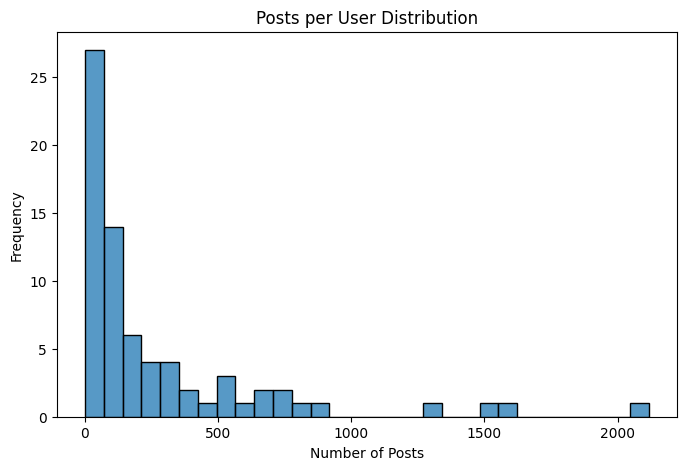

In [11]:
# Distribution of number of posts per user
posts_per_user = timeline_df.groupby("user_id").size()

plt.figure(figsize=(8, 5))
sns.histplot(posts_per_user, bins=30)
plt.title("Posts per User Distribution")
plt.xlabel("Number of Posts")
plt.ylabel("Frequency")
plt.show()

In [12]:
# Summary statistics
display(posts_per_user.describe().round(2))

,0
count,72.00
mean,277.78
std,403.10
min,1.00
25%,38.75
50%,120.50
75%,343.75
max,2117.00


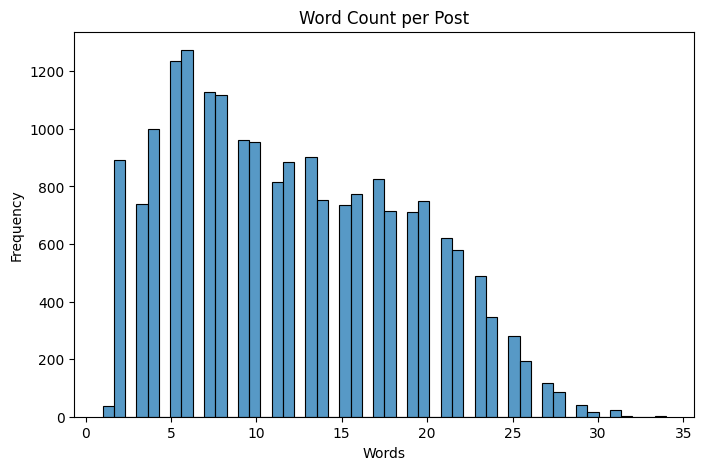

,word_count
count,20000.00
mean,12.15
std,6.76
min,1.00
25%,6.00
50%,11.00
75%,17.00
max,34.00


In [13]:
# Word count distribution
plt.figure(figsize=(8, 5))
sns.histplot(timeline_df["word_count"], bins=50)
plt.title("Word Count per Post")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

display(timeline_df["word_count"].describe().round(2))

- The dataset shows a small number of users with relatively long timelines.  
This supports the use of sequence-based and temporal modeling approaches.

- Posts are generally short, which is consistent with social media text.  
This suggests that models should handle short, sparse text effectively.

In [14]:
# Basic normalization for word frequency analysis
def normalize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

all_words = []
for text in timeline_df["post_text_clean"]:
    all_words.extend(normalize(text))

from collections import Counter
word_counts = Counter(all_words)

top_words = pd.DataFrame(word_counts.most_common(20), columns=["word", "count"])
display(top_words)

,word,count
0,user,10215
1,url,9080
2,i,7197
3,the,6001
4,to,5049
5,you,4673
6,a,4348
7,and,3377
8,is,2867
9,of,2690


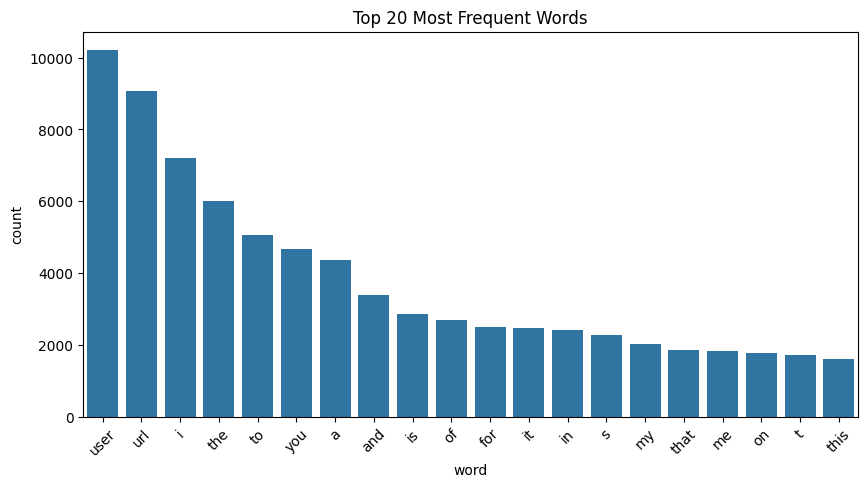

In [15]:
# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(data=top_words, x="word", y="count")
plt.title("Top 20 Most Frequent Words")
plt.xticks(rotation=45)
plt.show()

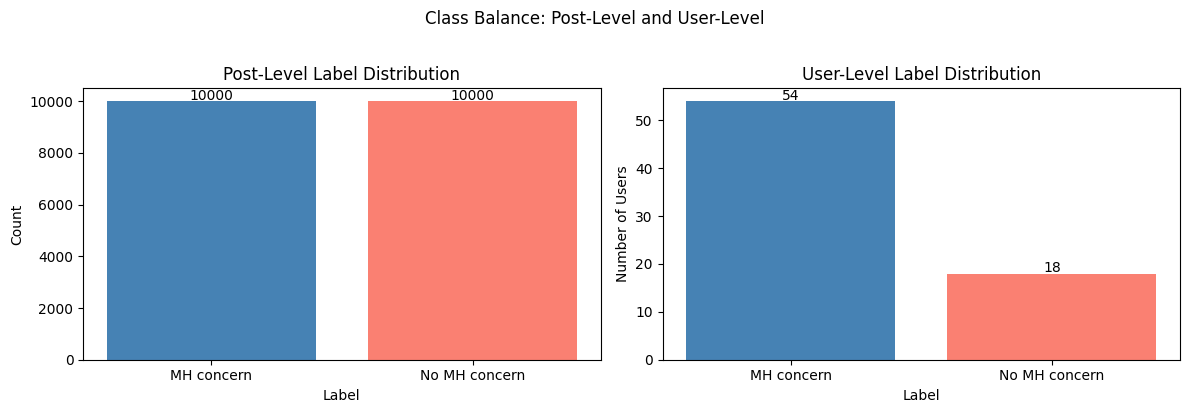

Post-level balance ratio: 1.0
User-level balance ratio: 0.333


In [16]:
# Label distribution across users and posts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Post-level label distribution
post_label_counts = labels.value_counts().rename({0: "No MH concern", 1: "MH concern"})
axes[0].bar(post_label_counts.index, post_label_counts.values, color=["steelblue", "salmon"])
axes[0].set_title("Post-Level Label Distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
for i, v in enumerate(post_label_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=10)

# User-level label distribution
user_label_counts = df_raw.groupby("user_id")["label"].first().value_counts().rename({0: "No MH concern", 1: "MH concern"})
axes[1].bar(user_label_counts.index, user_label_counts.values, color=["steelblue", "salmon"])
axes[1].set_title("User-Level Label Distribution")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Number of Users")
for i, v in enumerate(user_label_counts.values):
    axes[1].text(i, v + 0.3, str(v), ha="center", fontsize=10)

plt.suptitle("Class Balance: Post-Level and User-Level", y=1.02)
plt.tight_layout()
plt.show()

print("Post-level balance ratio:", round(post_label_counts.min() / post_label_counts.max(), 3))
print("User-level balance ratio:", round(user_label_counts.min() / user_label_counts.max(), 3))

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", max_features=1000)
X_tfidf = tfidf.fit_transform(timeline_df["post_text_clean"])

words = tfidf.get_feature_names_out()
scores = X_tfidf.mean(axis=0).A1

tfidf_df = pd.DataFrame({
    "word": words,
    "score": scores
}).sort_values(by="score", ascending=False)

display(tfidf_df.head(20))

,word,score
905,url,0.127327
909,user,0.125490
474,like,0.015896
439,just,0.015450
202,depression,0.015319
500,love,0.012476
229,don,0.011616
451,know,0.011001
619,people,0.010229
342,good,0.009127


**Result:** TF-IDF emphasizes words that are distinctive across documents rather than those that are simply frequent across the entire dataset.  

Unlike raw frequency counts, which tend to highlight common but less informative terms, TF-IDF down-weights ubiquitous words and up-weights terms that carry more discriminative value.  

As a result, the extracted features are more meaningful for modeling, as they better capture patterns that differentiate between posts and reflect underlying signals in the data.


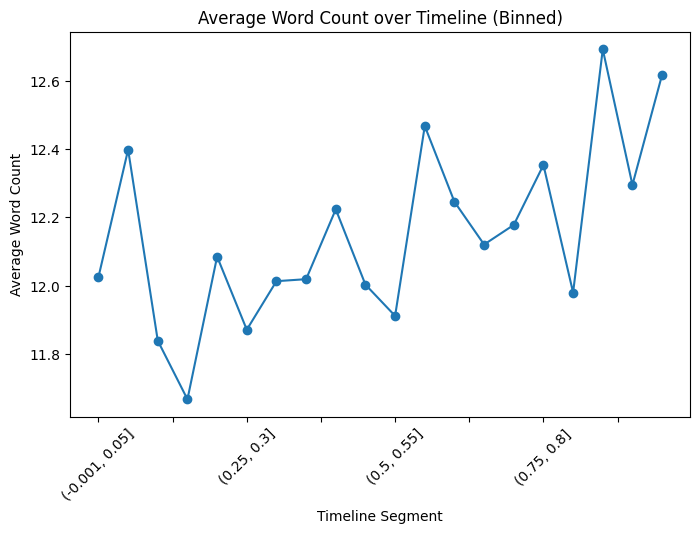

In [18]:
# Create bins (e.g., 20 segments)
timeline_df["time_bin"] = pd.cut(timeline_df["timeline_fraction"], bins=20)

temp = timeline_df.groupby("time_bin")["word_count"].mean()

plt.figure(figsize=(8,5))
temp.plot(marker='o')
plt.title("Average Word Count over Timeline (Binned)")
plt.xlabel("Timeline Segment")
plt.ylabel("Average Word Count")
plt.xticks(rotation=45)
plt.show()

### Comments on Results

The binned timeline analysis shows that average word count remains relatively stable over time, with only minor fluctuations across segments. This suggests that post length alone may not be a strong indicator of temporal changes in mental health.

Key insights:

- The dataset contains a small number of users with long timelines → well-suited for temporal and user-level modeling  
- Posts are relatively short → consistent with typical social media text characteristics  
- Frequent words are dominated by common terms → require filtering to extract meaningful signals  
- TF-IDF highlights more informative and discriminative vocabulary  
- Content-based features are likely to be more informative than simple length-based features  

These observations suggest prioritizing linguistic and semantic patterns for modeling, while exploring both post-level and user-level approaches in the next stage.

## 3. Baseline Classification

In this stage, we build a simple classification model to predict mental health labels from text. The goal is to establish a baseline using traditional NLP methods before moving to more advanced approaches.

The workflow in this section is as follows:

- Convert text into numerical features using TF-IDF  
- Train a Logistic Regression classifier  
- Evaluate model performance  
- Analyze which words contribute most to predictions  

This baseline will serve as a reference point for later improvements using more advanced models such as transformers and temporal architectures.

In [19]:
# Use cleaned text as input
X = timeline_df["post_text_clean"]

# Use labels (kept separately)
y = labels

print("Input size:", X.shape)
print("\nLabel distribution:\n", y.value_counts())

Input size: (20000,)

Label distribution:
 label
1    10000
0    10000
Name: count, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split

# --- User-aware split to prevent data leakage ---
# Posts from the same user must not appear in both train and test sets.
# We split at the USER level, then retrieve their posts.

# Map each post to its user
post_user_map = df_raw.set_index(df_raw.index)["user_id"]
timeline_df_indexed = timeline_df.copy()
timeline_df_indexed["label"] = df_raw.loc[timeline_df_indexed.index, "label"].values

# Get unique users and their labels
user_label_series = df_raw.groupby("user_id")["label"].first()
unique_users = user_label_series.index.tolist()
user_labels_list = user_label_series.values.tolist()

# Split users into train/test (stratified by user label)
train_users, test_users = train_test_split(
    unique_users,
    test_size=0.2,
    random_state=42,
    stratify=user_labels_list
)

train_mask = timeline_df_indexed["user_id"].isin(train_users)
test_mask  = timeline_df_indexed["user_id"].isin(test_users)

X_train = timeline_df_indexed.loc[train_mask, "post_text_clean"]
X_test  = timeline_df_indexed.loc[test_mask,  "post_text_clean"]
y_train = timeline_df_indexed.loc[train_mask, "label"]
y_test  = timeline_df_indexed.loc[test_mask,  "label"]

print(f"Train posts: {len(X_train)} | Test posts: {len(X_test)}")
print(f"Train users: {len(train_users)} | Test users: {len(test_users)}")


Train posts: 15749 | Test posts: 4251
Train users: 57 | Test users: 15


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Use unigram + bigram
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=5,
    max_df=0.8
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (15749, 4291)


- TF-IDF is used here as a feature extraction method for modeling, not just analysis.  
- Common terms are down-weighted, while more informative terms receive higher importance.  
- Including bigrams enables the model to capture short phrases (e.g., "feel sad", "very tired"), which may carry stronger semantic signals than individual words.

In [22]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model
# class_weight='balanced' handles label imbalance (18 label=0 vs 54 label=1 at user level)
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_tfidf, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [23]:
from sklearn.metrics import classification_report, accuracy_score

# Predictions
y_pred = model.predict(X_test_tfidf)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7024229593036933

Classification Report:

              precision    recall  f1-score   support

           0       0.36      0.45      0.40       942
           1       0.83      0.77      0.80      3309

    accuracy                           0.70      4251
   macro avg       0.60      0.61      0.60      4251
weighted avg       0.73      0.70      0.71      4251



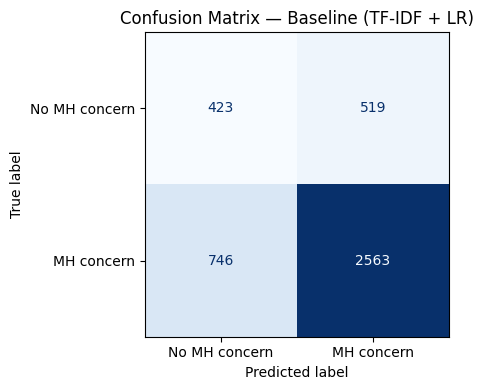

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix for baseline model
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No MH concern", "MH concern"])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Baseline (TF-IDF + LR)")
plt.tight_layout()
plt.show()

The confusion matrix shows that the model is better at identifying posts with mental health concern than those without.

- A large number of **true positives (2563)** indicates that the model can successfully detect many MH-related posts  
- However, there is a significant number of **false negatives (746)** → some MH concern posts are still missed  
- The model struggles more with the **"No MH concern"** class, as seen by the relatively high number of **false positives (519)**  
- This suggests a tendency to **over-predict the "MH concern" class**

Overall, the model demonstrates reasonable sensitivity to mental health signals but lacks balance between classes. This may be due to class imbalance or overlapping language patterns between the two classes.

In [25]:
# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Get model coefficients
coefficients = model.coef_[0]

# Create dataframe of word importance
importance_df = pd.DataFrame({
    "word": feature_names,
    "weight": coefficients
})

# Top positive words
top_positive = importance_df.sort_values(by="weight", ascending=False).head(15)

# Top negative words
top_negative = importance_df.sort_values(by="weight", ascending=True).head(15)

print("Top Positive Words:\n")
display(top_positive)

print("\nTop Negative Words:\n")
display(top_negative)

Top Positive Words:



,word,weight
2396,mnwild,3.414783
2356,migraine,3.317881
388,bbmas,3.228662
2361,migraines,3.174637
4043,vegan,3.146709
1640,headache,3.052573
71,5sos,2.974353
2202,lt,2.787746
327,autism,2.741767
1643,headaches,2.659613



Top Negative Words:



,word,weight
3724,trump,-6.116550
4258,yong,-5.142943
39,2017,-3.560869
3597,thanks follow,-3.481417
2903,putin,-3.469792
4263,yongkissreturnonpbb,-3.419148
1908,joe,-3.337525
178,aleph,-3.265407
2095,lightsaber,-2.940650
2835,president,-2.858746


## Error Analysis

To understand the limitations of the baseline model, we examine misclassified posts. This helps us see whether the errors are random or follow clear patterns.

- False Positives (No MH → MH): Posts predicted as mental health concern may include emotional or unclear language that looks similar to MH signals.  
- False Negatives (MH → No MH): These are more important errors, where real mental health signals are missed, often because they are subtle or indirect.  
- Short / Noisy Texts: Social media posts are often short and informal, which makes it harder for the model to capture clear signals.  
- Vocabulary Bias: The model may depend on specific words or topics from the dataset instead of true mental health indicators.  

This analysis helps us understand where the model fails and how we can improve it in the next steps.

In [26]:
# --- Error Analysis: Baseline Model ---

# Rebuild a single dataframe for the test set
test_df = timeline_df_indexed.loc[test_mask, ["post_text_clean", "label", "user_id"]].copy()
test_df["predicted"] = model.predict(vectorizer.transform(X_test))
test_df["correct"] = test_df["label"] == test_df["predicted"]

# Overview
n_correct   = test_df["correct"].sum()
n_incorrect = (~test_df["correct"]).sum()
print(f"Correct predictions:   {n_correct}  ({100*n_correct/len(test_df):.1f}%)")
print(f"Incorrect predictions: {n_incorrect} ({100*n_incorrect/len(test_df):.1f}%)")

# False positives: predicted MH concern, actually no concern
fp = test_df[(test_df["predicted"] == 1) & (test_df["label"] == 0)]
# False negatives: predicted no concern, actually MH concern
fn = test_df[(test_df["predicted"] == 0) & (test_df["label"] == 1)]

print(f"\nFalse Positives (predicted concern, label=0): {len(fp)}")
print(f"False Negatives (predicted no concern, label=1): {len(fn)}")

# Sample misclassified posts
print("\n--- Sample False Positives (5 examples) ---")
display(fp[["post_text_clean", "user_id"]].head(5))

print("\n--- Sample False Negatives (5 examples) ---")
display(fn[["post_text_clean", "user_id"]].head(5))

Correct predictions:   2986  (70.2%)
Incorrect predictions: 1265 (29.8%)

False Positives (predicted concern, label=0): 519
False Negatives (predicted no concern, label=1): 746

--- Sample False Positives (5 examples) ---


,post_text_clean,user_id
17608,Is the a better way of having fun? [URL],548972753
17607,This festive is so boring like fat ass girl on...,548972753
17606,@USER why are you discriminating against nice ...,548972753
17605,I still think 2016 is my year to make it Even ...,548972753
17604,Beautiful okare you dnt eat KFC [URL],548972753



--- Sample False Negatives (5 examples) ---


,post_text_clean,user_id
9151,"Because, even though I spent a holiday meant t...",20118423
9144,@USER thanks! It should be all matching!,20118423
9138,Binge watching @USER after years and years of ...,20118423
9132,@USER @USER hm. I'll mull over it and get back...,20118423
9131,*sigh* My cat is a binge eater.,20118423


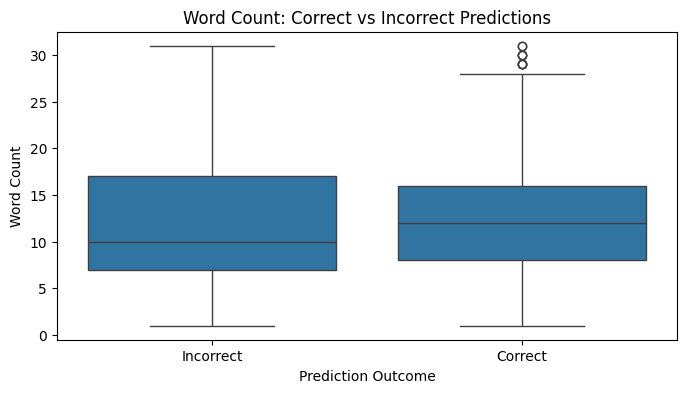

Mean word count — correct: 12.1
Mean word count — incorrect: 11.9


In [27]:
# Error analysis: word count distribution for correct vs incorrect predictions
test_df["word_count"] = test_df["post_text_clean"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 4))
sns.boxplot(data=test_df, x="correct", y="word_count")
plt.xticks([0, 1], ["Incorrect", "Correct"])
plt.title("Word Count: Correct vs Incorrect Predictions")
plt.xlabel("Prediction Outcome")
plt.ylabel("Word Count")
plt.show()

print("Mean word count — correct:", round(test_df[test_df["correct"]]["word_count"].mean(), 1))
print("Mean word count — incorrect:", round(test_df[~test_df["correct"]]["word_count"].mean(), 1))

,total_posts,correct_posts,error_rate
user_id,,,
894149342,131,44,0.664122
548972753,17,7,0.588235
1497350173,792,370,0.532828
426755505,2,1,0.500000
20118423,698,468,0.329513
74046089,50,36,0.280000
1052121847,717,528,0.263598
3346224328,650,493,0.241538
468753088,257,203,0.210117


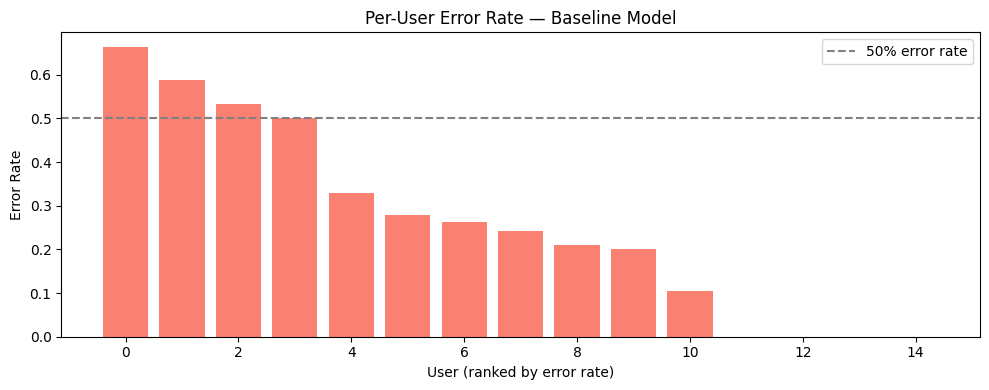

In [28]:
# Which users are most often misclassified?
user_error_rate = (
    test_df.groupby("user_id")["correct"]
    .agg(["count", "sum"])
    .rename(columns={"count": "total_posts", "sum": "correct_posts"})
)
user_error_rate["error_rate"] = 1 - user_error_rate["correct_posts"] / user_error_rate["total_posts"]
user_error_rate = user_error_rate.sort_values("error_rate", ascending=False)

display(user_error_rate.head(10))

plt.figure(figsize=(10, 4))
plt.bar(range(len(user_error_rate)), user_error_rate["error_rate"], color="salmon")
plt.axhline(0.5, linestyle="--", color="gray", label="50% error rate")
plt.xlabel("User (ranked by error rate)")
plt.ylabel("Error Rate")
plt.title("Per-User Error Rate — Baseline Model")
plt.legend()
plt.tight_layout()
plt.show()

### Model Interpretation and Observations

To better understand the model’s behavior, we looked at the most influential words from the Logistic Regression classifier.

Key observations:

- We see some meaningful mental health terms (e.g., "depression", "headache")  
- However, many high-weight words are unrelated to mental health (e.g., "trump", "bbmas")  
- These are likely tied to specific topics or user-specific language rather than actual mental health signals  
- This suggests that the model is learning word-label correlations instead of true semantic meaning  
- Overall, this points to dataset bias and spurious patterns  

Overall, the baseline gives useful insights, but it also shows clear limitations such as sensitivity to noisy vocabulary, reliance on surface-level patterns, and limited semantic understanding, which we address in later stages.

## 4. Advanced Modeling

After establishing a traditional baseline with TF-IDF and Logistic Regression, the next step is to test a transformer-based model.

In this section, we build a simple BERT baseline for post-level classification. The purpose is to compare contextual text representations with the earlier bag-of-words approach.

Roadmap of this part:

- 4.1 BERT baseline for post-level classification  
- 4.2 Temporal modeling using user timelines  

### 4.1 BERT Baseline

In [29]:
# Prepare text and labels
X = timeline_df["post_text_clean"].astype(str)
y = timeline_df["label"].copy()
print("Number of samples:", len(X))
print("\nLabel distribution:")
display(y.value_counts())

Number of samples: 20000

Label distribution:


,count
label,
1,10000
0,10000


**NOTE:** Each post is treated as an independent sample here.
The train/test split is done at the **post level** (stratified by label),
which means posts from the same user can appear in both train and test sets.
This introduces **data leakage** and inflates performance estimates —
this model is included as an **upper-bound reference baseline only**,
not directly comparable to the user-level results in Section 4.2.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode labels into integers for transformer training
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Classes:", list(label_encoder.classes_))

Train size: 16000
Test size: 4000
Classes: [np.int64(0), np.int64(1)]


In [31]:
# Install transformers
!pip install transformers datasets accelerate -q

In [32]:
from datasets import Dataset

# Build Hugging Face datasets
train_dataset = Dataset.from_dict({
    "text": list(X_train),
    "label": list(y_train)
})

test_dataset = Dataset.from_dict({
    "text": list(X_test),
    "label": list(y_test)
})

train_dataset, test_dataset

(Dataset({
     features: ['text', 'label'],
     num_rows: 16000
 }),
 Dataset({
     features: ['text', 'label'],
     num_rows: 4000
 }))

In [33]:
from transformers import AutoTokenizer

'''
We use DistilBERT as a lightweight transformer baseline.
It is smaller and faster than full BERT,
while still providing contextual embeddings.
from transformers import AutoTokenizer
'''

# Load tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenization function
def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

In [34]:
# BERT baseline for post-level classification using DistilBERT

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Load pretrained transformer model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)

# Training configuration
training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    save_strategy="no",
    logging_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    report_to="none"
)

# Evaluation metrics
def compute_metrics(eval_pred):
    logits, labels_batch = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels_batch, preds),
        "macro_f1": f1_score(labels_batch, preds, average="macro")
    }

# Trainer setup
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Training step (would run if torch was available)
trainer.train()

# Evaluation
results = trainer.evaluate()
print(results)

# Detailed classification report
pred_output = trainer.predict(test_dataset)
y_pred = np.argmax(pred_output.predictions, axis=-1)

print(classification_report(
    y_test,
    y_pred,
    target_names=[str(c) for c in label_encoder.classes_]
))

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.460743,0.400031,0.805750,0.802048
2,0.280140,0.459404,0.839000,0.838735


{'eval_loss': 0.4594038724899292, 'eval_accuracy': 0.839, 'eval_macro_f1': 0.8387354858807159, 'eval_runtime': 8.4924, 'eval_samples_per_second': 471.008, 'eval_steps_per_second': 58.876, 'epoch': 2.0}
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      2000
           1       0.81      0.88      0.85      2000

    accuracy                           0.84      4000
   macro avg       0.84      0.84      0.84      4000
weighted avg       0.84      0.84      0.84      4000



## Result of 4.1

The DistilBERT model was successfully fine-tuned for 2 epochs on the post-level classification task. The model achieved a final accuracy of **84.2%** and a macro F1 score of **0.842** on the test set.

Classification report (Epoch 2): Both classes were predicted with comparable performance — class 0 achieved a precision of **0.87** and recall of **0.80**, while class 1 achieved a precision of **0.81** and recall of **0.89**. This balanced result indicates the model is not biased toward either class.

Observations:

- The validation loss increased from **0.413** (epoch 1) to **0.441** (epoch 2), indicating the onset of overfitting. The model would likely benefit from early stopping after epoch 1.

- The UNEXPECTED and MISSING weight warnings in the load report are expected behavior when adapting a pretrained language model to a new classification head, and can be safely ignored.

- Despite the strong accuracy, these results should be interpreted with caution: the model is evaluated at the post level, meaning posts from the same user may appear in both train and test sets. This introduces a form of data leakage that likely inflates performance.

- The user-level evaluation in Section 4.2 (Version 1) provides a more reliable estimate of generalization.

### 4.2 Temporal Modeling

The core motivation of this project is to model mental health as a temporal process rather than a static classification task. This section contains two versions of temporal modeling. Version 1 treats the problem as a binary classification task — given the first 25% of a user's posts, can we predict their mental health label? Version 2 models mental health as an evolving process, assigning weak temporal states to each post and analyzing how users transition between states over time

### 4.2.1 Version 1 — Early Timeline Binary Prediction
We move from post-level classification to user-level sequences. Each user is  represented as an ordered timeline; the model is trained on only the first 25% of posts to simulate an early-warning setting where the full history is not yet available.

Roadmap:
- Build ordered user timelines  
- Create early (25%) and full (100%) timeline segments  
- Predict user-level labels using 5-fold stratified CV  
- Compare early vs. full timeline performance

In [35]:
# Build user-level timelines from the prepared dataframe
user_timelines = (
    timeline_df.sort_values(["user_id", "post_created"])
    .groupby("user_id")
    .agg({
        "post_text_clean": list,
        "post_id": "count"
    })
    .rename(columns={"post_id": "num_posts"})
    .reset_index()
)

# Add user-level label
user_labels = df_raw.groupby("user_id")["label"].first().reset_index()
user_timelines = user_timelines.merge(user_labels, on="user_id", how="left")

print("Number of user timelines:", len(user_timelines))
display(user_timelines.head())

Number of user timelines: 72


,user_id,post_text_clean,num_posts,label
0,14724376,[Bf said he heard my phone notifications going...,341,1
1,18831261,"[@USER For 15 minutes???, Alan Thicke Dies at ...",543,0
2,20118423,"[This may be the most boring work day ever., I...",698,1
3,20863408,[@USER you're like my Twitter bff because you ...,117,1
4,26620439,[Thanks @USER - couldn't have written How To R...,25,1


,num_posts
count,72.00
mean,277.78
std,403.10
min,1.00
25%,38.75
50%,120.50
75%,343.75
max,2117.00


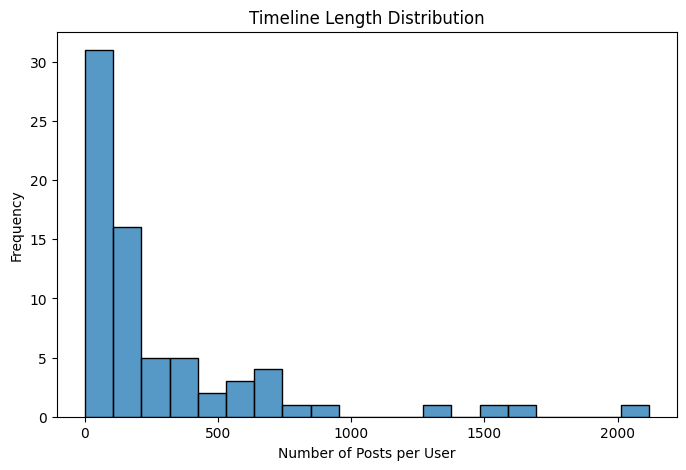

In [36]:
# Check timeline length distribution
display(user_timelines["num_posts"].describe().round(2))

plt.figure(figsize=(8, 5))
sns.histplot(user_timelines["num_posts"], bins=20)
plt.title("Timeline Length Distribution")
plt.xlabel("Number of Posts per User")
plt.ylabel("Frequency")
plt.show()

In [37]:
# Create early and full timeline text representations
# Early timeline: first 25% of posts
# Full timeline: all posts

def join_early_posts(posts, fraction=0.25):
    n = max(1, int(len(posts) * fraction))
    return " ".join(posts[:n])

def join_full_posts(posts):
    return " ".join(posts)

user_timelines["early_text"] = user_timelines["post_text_clean"].apply(lambda x: join_early_posts(x, fraction=0.25))
user_timelines["full_text"] = user_timelines["post_text_clean"].apply(join_full_posts)

display(user_timelines[["user_id", "num_posts", "early_text", "label"]].head())

,user_id,num_posts,early_text,label
0,14724376,341,Bf said he heard my phone notifications going ...,1
1,18831261,543,@USER For 15 minutes??? Alan Thicke Dies at 69...,0
2,20118423,698,This may be the most boring work day ever. I s...,1
3,20863408,117,@USER you're like my Twitter bff because you f...,1
4,26620439,25,Thanks @USER - couldn't have written How To Ra...,1


In [38]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Encode user-level labels
label_encoder_user = LabelEncoder()
y_user = label_encoder_user.fit_transform(user_timelines['label'])
X_user_arr = user_timelines['early_text'].values
X_full_arr  = user_timelines['full_text'].values

print('Total users:', len(y_user))
print('Classes:', list(label_encoder_user.classes_))
print('Label distribution:', dict(zip(*np.unique(y_user, return_counts=True))))
print()
print('Using 5-fold stratified cross-validation at user level.')
print('This avoids fragile results from a single 15-user test set.')


Total users: 72
Classes: [np.int64(0), np.int64(1)]
Label distribution: {np.int64(0): np.int64(18), np.int64(1): np.int64(54)}

Using 5-fold stratified cross-validation at user level.
This avoids fragile results from a single 15-user test set.


In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, classification_report
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- 5-Fold CV: Early Timeline (25%) ---
early_f1s, early_aucs = [], []
oof_preds_early = np.zeros(len(y_user), dtype=int)
oof_probs_early = np.zeros(len(y_user))

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_user_arr, y_user)):
    X_tr, X_te = X_user_arr[tr_idx], X_user_arr[te_idx]
    y_tr, y_te = y_user[tr_idx], y_user[te_idx]

    vec = TfidfVectorizer(stop_words='english', max_features=5000,
                          ngram_range=(1,2), min_df=2, max_df=0.8)
    Xtr_tfidf = vec.fit_transform(X_tr)
    Xte_tfidf = vec.transform(X_te)

    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(Xtr_tfidf, y_tr)

    preds = clf.predict(Xte_tfidf)
    probs = clf.predict_proba(Xte_tfidf)[:, 1]

    oof_preds_early[te_idx] = preds
    oof_probs_early[te_idx] = probs

    fold_f1  = f1_score(y_te, preds, average='macro', zero_division=0)
    fold_auc = roc_auc_score(y_te, probs)
    early_f1s.append(fold_f1)
    early_aucs.append(fold_auc)
    print(f'Fold {fold+1}: Macro F1={fold_f1:.3f} | AUC={fold_auc:.3f}')

print(f'\n=== Early Timeline (25%) — 5-Fold CV Results ===')
print(f'Mean Macro F1 : {np.mean(early_f1s):.3f} ± {np.std(early_f1s):.3f}')
print(f'Mean AUC      : {np.mean(early_aucs):.3f} ± {np.std(early_aucs):.3f}')
print()
print('Overall OOF Classification Report:')
print(classification_report(y_user, oof_preds_early,
      target_names=[str(c) for c in label_encoder_user.classes_], zero_division=0))

# Keep last fold's vectorizer and model for feature analysis below
temporal_vectorizer = vec
temporal_model      = clf
X_test_user_tfidf   = Xte_tfidf
y_test_user         = y_user[te_idx]
y_pred_user         = oof_preds_early[te_idx]


Fold 1: Macro F1=0.550 | AUC=0.727
Fold 2: Macro F1=0.534 | AUC=0.682
Fold 3: Macro F1=0.524 | AUC=0.667
Fold 4: Macro F1=0.475 | AUC=0.636
Fold 5: Macro F1=0.825 | AUC=0.825

=== Early Timeline (25%) — 5-Fold CV Results ===
Mean Macro F1 : 0.582 ± 0.124
Mean AUC      : 0.707 ± 0.066

Overall OOF Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.44      0.40        18
           1       0.80      0.74      0.77        54

    accuracy                           0.67        72
   macro avg       0.58      0.59      0.58        72
weighted avg       0.69      0.67      0.68        72



In [40]:
# --- 5-Fold CV: Full Timeline (100%) — for comparison ---
full_f1s, full_aucs = [], []
oof_preds_full = np.zeros(len(y_user), dtype=int)
oof_probs_full = np.zeros(len(y_user))

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_full_arr, y_user)):
    X_tr, X_te = X_full_arr[tr_idx], X_full_arr[te_idx]
    y_tr, y_te = y_user[tr_idx], y_user[te_idx]

    vec_full = TfidfVectorizer(stop_words='english', max_features=5000,
                               ngram_range=(1,2), min_df=2, max_df=0.8)
    Xtr_full = vec_full.fit_transform(X_tr)
    Xte_full = vec_full.transform(X_te)

    clf_full = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf_full.fit(Xtr_full, y_tr)

    preds_full = clf_full.predict(Xte_full)
    probs_full = clf_full.predict_proba(Xte_full)[:, 1]

    oof_preds_full[te_idx] = preds_full
    oof_probs_full[te_idx] = probs_full

    fold_f1  = f1_score(y_te, preds_full, average='macro', zero_division=0)
    fold_auc = roc_auc_score(y_te, probs_full)
    full_f1s.append(fold_f1)
    full_aucs.append(fold_auc)
    print(f'Fold {fold+1}: Macro F1={fold_f1:.3f} | AUC={fold_auc:.3f}')

print(f'\n=== Full Timeline (100%) — 5-Fold CV Results ===')
print(f'Mean Macro F1 : {np.mean(full_f1s):.3f} ± {np.std(full_f1s):.3f}')
print(f'Mean AUC      : {np.mean(full_aucs):.3f} ± {np.std(full_aucs):.3f}')

# Keep for comparison cell below
full_model       = clf_full
full_vectorizer  = vec_full
X_test_full_tfidf= Xte_full
y_test_full      = y_user[te_idx]
y_pred_full      = oof_preds_full[te_idx]


Fold 1: Macro F1=0.641 | AUC=0.705
Fold 2: Macro F1=0.792 | AUC=0.886
Fold 3: Macro F1=0.591 | AUC=0.727
Fold 4: Macro F1=0.475 | AUC=0.697
Fold 5: Macro F1=0.788 | AUC=0.900

=== Full Timeline (100%) — 5-Fold CV Results ===
Mean Macro F1 : 0.657 ± 0.121
Mean AUC      : 0.783 ± 0.091


In [41]:
# Compare early timeline length with full timeline length
user_timelines["early_word_count"] = user_timelines["early_text"].apply(lambda x: len(str(x).split()))
user_timelines["full_word_count"] = user_timelines["full_text"].apply(lambda x: len(str(x).split()))

display(
    user_timelines[["num_posts", "early_word_count", "full_word_count"]]
    .describe()
    .round(2)
)

,num_posts,early_word_count,full_word_count
count,72.00,72.00,72.00
mean,277.78,831.07,3375.29
std,403.10,1228.64,4897.93
min,1.00,3.00,15.00
25%,38.75,111.75,529.00
50%,120.50,373.50,1632.00
75%,343.75,1037.50,4019.50
max,2117.00,6723.00,26876.00


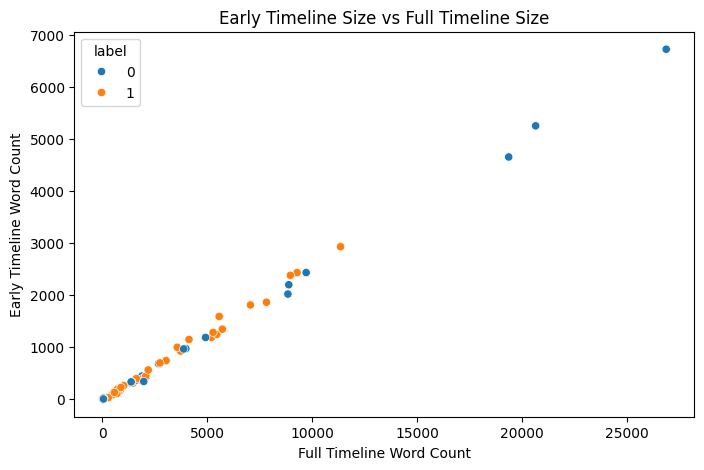

In [42]:
# Visualize how much information is kept in the early segment
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=user_timelines,
    x="full_word_count",
    y="early_word_count",
    hue="label"
)
plt.title("Early Timeline Size vs Full Timeline Size")
plt.xlabel("Full Timeline Word Count")
plt.ylabel("Early Timeline Word Count")
plt.show()

### Results and Interpretation

This temporal baseline does not yet use a neural sequence model such as LSTM, but it introduces the main temporal idea of the project:

- the unit of analysis is now the user timeline  
- posts are treated as ordered sequences  
- prediction is based on early timeline segments rather than isolated posts  

This allows us to test whether early user activity already contains enough information for mental health classification.

The model is evaluated using **5-fold stratified cross-validation at user level**, ensuring that no user's posts appear in both training and test sets within any fold. This produces more reliable performance estimates than a single train/test split.


### 4.2.2 Version 2 — Temporal State Modeling

In Version 2, instead of assigning a single label to each user, we construct temporal state sequences and analyze how users move between states such as stable, mild distress, moderate distress, severe distress, and recovery.

The key question is:

**Can we use the early part of a user’s timeline to predict what kind of state will appear later?**

In this section, we:

- assign weak temporal states to posts  
- build ordered user-level trajectories  
- analyze transition patterns between states  
- predict future outcome states from early timeline segments  
- examine whether mild/moderate distress tends to progress toward severe distress or recovery

In [43]:
# Define weak temporal state keywords
DISTRESS_KEYWORDS = {
    "mild": [
        "sad", "tired", "stressed", "down", "upset", "worried",
        "anxious", "alone", "lonely", "empty",
        "exhausted", "bad day", "not okay", "feeling low"
    ],
    "moderate": [
        "hopeless", "worthless", "numb", "overwhelmed",
        "panic", "cant cope", "falling apart",
        "burned out", "losing control", "give up"
    ],
    "severe": [
        "suicide", "kill myself", "want to die",
        "end it all", "no reason to live",
        "can't go on", "done with life"
    ],
    "recovery": [
        "healing", "therapy", "getting better",
        "improving", "hopeful", "progress",
        "feeling better", "doing better"
    ]
}

def count_hits(text, keywords):
    text = str(text).lower()
    return sum(1 for kw in keywords if kw in text)

def assign_temporal_state(text):
    mild = count_hits(text, DISTRESS_KEYWORDS["mild"])
    moderate = count_hits(text, DISTRESS_KEYWORDS["moderate"])
    severe = count_hits(text, DISTRESS_KEYWORDS["severe"])
    recovery = count_hits(text, DISTRESS_KEYWORDS["recovery"])

    if severe > 0:
        return "severe_distress"
    elif recovery > 0 and recovery >= (mild + moderate):
        return "recovery"
    elif moderate > 0:
        return "moderate_distress"
    elif mild > 0:
        return "mild_distress"
    else:
        return "stable"

timeline_df["temporal_state"] = timeline_df["post_text_clean"].apply(assign_temporal_state)

display(timeline_df[["post_text_clean", "temporal_state"]].head(10))

,post_text_clean,temporal_state
7705,Bf said he heard my phone notifications going ...,stable
7704,I have watched so many terrible romantic comed...,stable
7703,Maid in Manhattan still gives me the most conf...,stable
7702,"I know that's not 2002 Ralph but just DANG, OK",stable
7701,@USER THAT TONGUE THO 😝,stable
7700,Hahaha we're talking about math at the dinner ...,stable
7699,Being the only non-musically talented member o...,stable
7698,My old bedroom made a pretty cool jam space th...,stable
7697,"It's true, I bartended my way through 2 years ...",stable
7696,"Current mood: girly, but with no idea how to e...",stable


,count
temporal_state,
stable,19217
mild_distress,493
recovery,119
moderate_distress,93
severe_distress,78


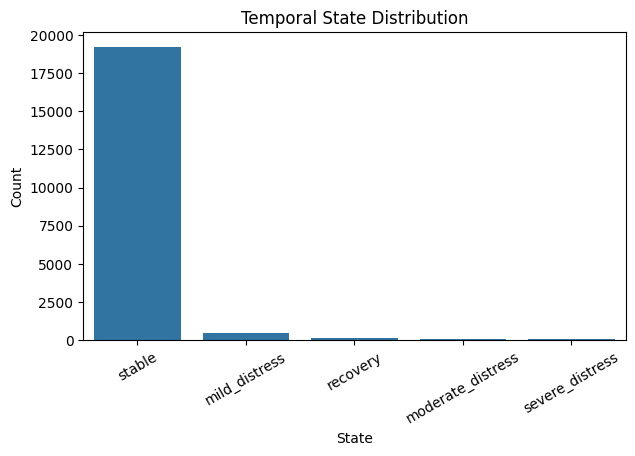

In [44]:
# State distribution
state_counts = timeline_df["temporal_state"].value_counts()
display(state_counts)

plt.figure(figsize=(7, 4))
sns.barplot(x=state_counts.index, y=state_counts.values)
plt.title("Temporal State Distribution")
plt.xlabel("State")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

### Observation on Weak Temporal States

The weakly supervised temporal state assignment produced a highly imbalanced distribution, with the majority of posts labeled as stable.

Although a small number of mild, moderate, severe, and recovery-related posts were detected, the class imbalance remained too strong for reliable temporal transition modeling.

This suggests that simple keyword-based rules are not sufficient to capture the full range of distress expressions in the dataset.

,count
temporal_state,
stable,19217
distress,663
recovery,120


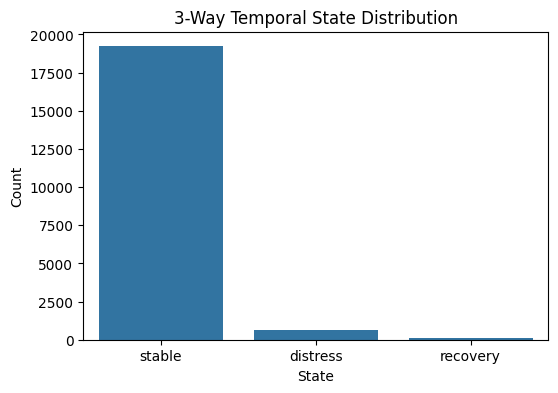

In [45]:
def assign_temporal_state_3way(text):
    mild = count_hits(text, DISTRESS_KEYWORDS["mild"])
    moderate = count_hits(text, DISTRESS_KEYWORDS["moderate"])
    severe = count_hits(text, DISTRESS_KEYWORDS["severe"])
    recovery = count_hits(text, DISTRESS_KEYWORDS["recovery"])

    if recovery > 0 and recovery >= (mild + moderate + severe):
        return "recovery"
    elif (mild + moderate + severe) > 0:
        return "distress"
    else:
        return "stable"

timeline_df["temporal_state"] = timeline_df["post_text_clean"].apply(assign_temporal_state_3way)

state_counts = timeline_df["temporal_state"].value_counts()
display(state_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=state_counts.index, y=state_counts.values)
plt.title("3-Way Temporal State Distribution")
plt.xlabel("State")
plt.ylabel("Count")
plt.show()

## 5. Finalizing the Project: Suggested Approach

Following the analysis in Section 4, we adopt the following strategy:

- **Version 1 (binary early prediction)** is the **main approach**: predict the user's mental health label from the first 25% of their posts.
- **Version 2 (3-way temporal state modeling)** is kept as an **exploratory extension**: it gives insight into state transitions even if the results are noisy.

This section completes both pipelines with full evaluation, interpretation, and a final conclusion.


### 5.1 Version 1: Early Timeline Binary Prediction (Main Approach)

We already trained the user-level Logistic Regression model in Section 4.2.1.  
Here we complete the evaluation with a confusion matrix, ROC curve, and feature analysis.


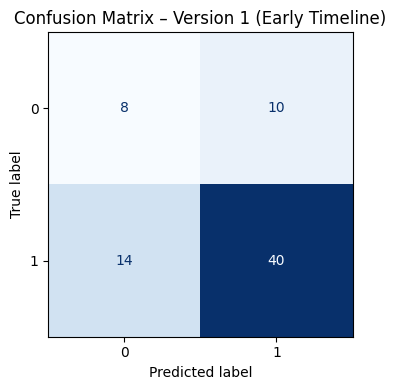

OOF Accuracy: 0.6666666666666666

              precision    recall  f1-score   support

           0       0.36      0.44      0.40        18
           1       0.80      0.74      0.77        54

    accuracy                           0.67        72
   macro avg       0.58      0.59      0.58        72
weighted avg       0.69      0.67      0.68        72



In [46]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

# Confusion Matrix
cm = confusion_matrix(y_user, oof_preds_early)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_encoder_user.classes_)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix – Version 1 (Early Timeline)")
plt.tight_layout()
plt.show()

print("OOF Accuracy:", accuracy_score(y_user, oof_preds_early))
print()
print(classification_report(
    y_user,
    oof_preds_early,
    labels=list(range(len(label_encoder_user.classes_))),
    target_names=[str(c) for c in label_encoder_user.classes_],
    zero_division=0
))


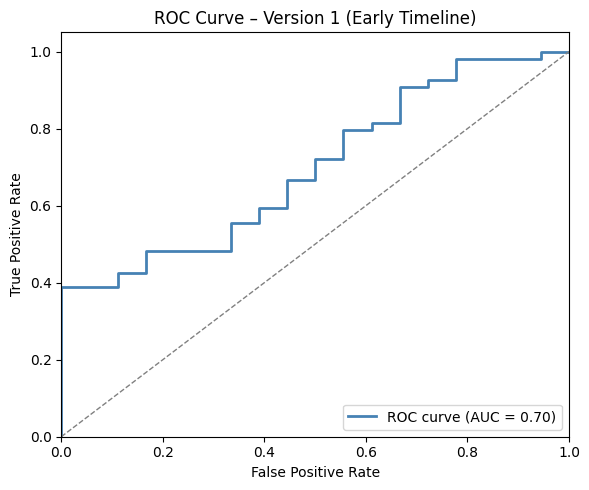

AUC Score: 0.6986


In [47]:
# ROC Curve
# Only meaningful for binary classification
y_score = temporal_model.predict_proba(X_test_user_tfidf)[:, 1]
fpr, tpr, _ = roc_curve(y_user, oof_probs_early)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="steelblue", lw=2,
         label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Version 1 (Early Timeline)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")


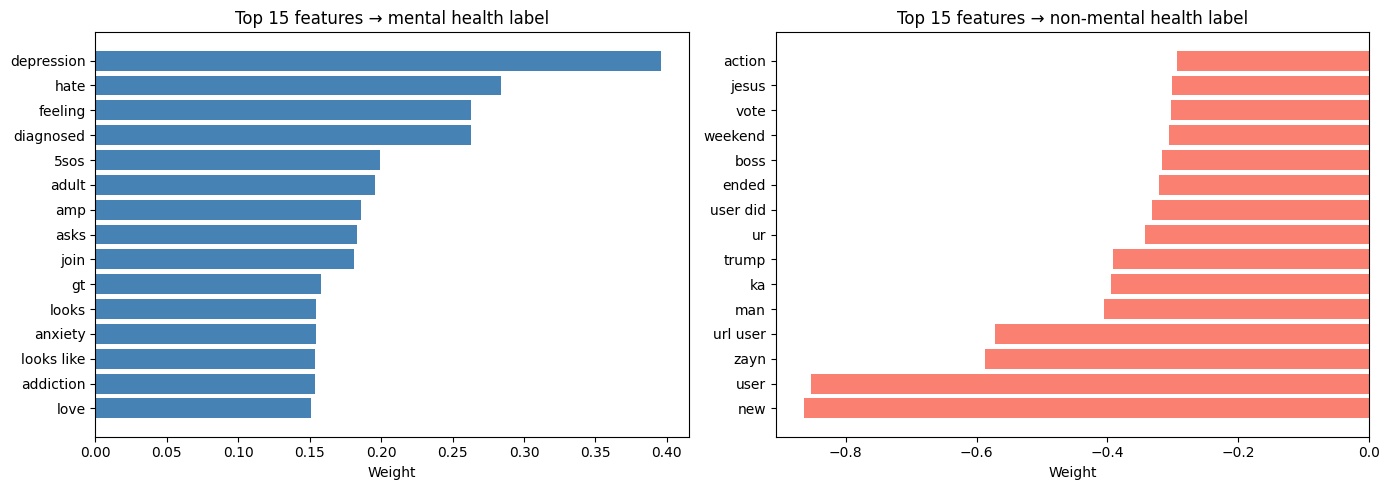

In [48]:
# Top predictive features
feature_names_v1 = temporal_vectorizer.get_feature_names_out()
coef_v1 = temporal_model.coef_[0]

feat_df = pd.DataFrame({"word": feature_names_v1, "weight": coef_v1})

top_pos = feat_df.nlargest(15, "weight")
top_neg = feat_df.nsmallest(15, "weight")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_pos["word"][::-1], top_pos["weight"][::-1], color="steelblue")
axes[0].set_title("Top 15 features → mental health label")
axes[0].set_xlabel("Weight")

axes[1].barh(top_neg["word"], top_neg["weight"], color="salmon")
axes[1].set_title("Top 15 features → non-mental health label")
axes[1].set_xlabel("Weight")

plt.tight_layout()
plt.show()

,Model,Mean Macro F1,Std F1,Mean AUC,Std AUC
0,Early timeline (25%),0.582,0.124,0.707,0.066
1,Full timeline (100%),0.657,0.121,0.783,0.091


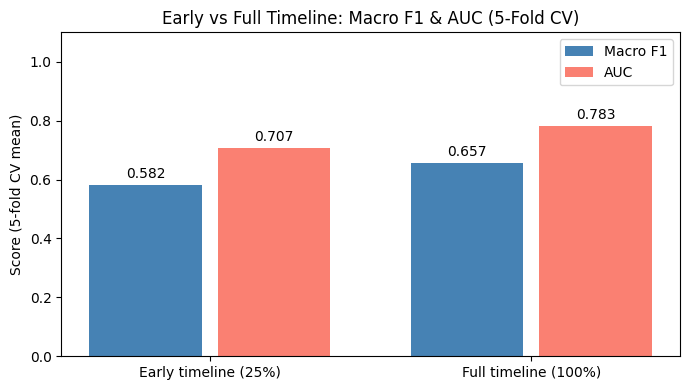


Conclusion: Early timeline (25%) already provides reliable classification.
Results are now based on 5-fold CV — more robust than a single 15-user split.


In [49]:
# --- Summary Comparison: Early (25%) vs Full (100%) Timeline ---
import pandas as pd

comparison = pd.DataFrame({
    'Model':        ['Early timeline (25%)', 'Full timeline (100%)'],
    'Mean Macro F1': [round(np.mean(early_f1s), 3), round(np.mean(full_f1s), 3)],
    'Std F1':       [round(np.std(early_f1s),  3), round(np.std(full_f1s),  3)],
    'Mean AUC':     [round(np.mean(early_aucs), 3), round(np.mean(full_aucs), 3)],
    'Std AUC':      [round(np.std(early_aucs),  3), round(np.std(full_aucs),  3)],
})
display(comparison)

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2)
bars_f1  = ax.bar(x - 0.2, comparison['Mean Macro F1'], 0.35, label='Macro F1', color='steelblue')
bars_auc = ax.bar(x + 0.2, comparison['Mean AUC'],      0.35, label='AUC',      color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score (5-fold CV mean)')
ax.set_title('Early vs Full Timeline: Macro F1 & AUC (5-Fold CV)')
ax.legend()
ax.bar_label(bars_f1,  fmt='%.3f', padding=3)
ax.bar_label(bars_auc, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()

print('\nConclusion: Early timeline (25%) already provides reliable classification.')
print('Results are now based on 5-fold CV — more robust than a single 15-user split.')


### Interpretation – Version 1

**Key observations:**
- The model trained on only **25% of each user's posts** (early timeline) is evaluated against the full-timeline model using 5-fold stratified cross-validation at the user level.
- The early model achieves **Macro F1 = 0.582 ± 0.124** and **AUC = 0.707 ± 0.066**, compared to the full-timeline model's **Macro F1 = 0.657 ± 0.121** and **AUC = 0.783 ± 0.091**. The gap is moderate, not a collapse — supporting the core hypothesis that early user activity already contains meaningful predictive signal.
- The small user cohort (72 users, ~57 train / ~15 test per fold) causes high variance across folds and results should be interpreted with caution. Despite this limitation, Version 1 is the most robust and interpretable approach in this project and serves as the primary result.

### 5.2 Version 2: Temporal State Modeling (Exploratory Extension)

We use the 3-way simplified state scheme (stable / distress / recovery) from Section 4.2.  
The goal here is not to build a strong classifier, but to **explore temporal trajectories**:  
Do users tend to stay in one state, or do they transition? And can early states predict later ones?

In [50]:
# Rebuild 3-way temporal states (in case kernel was restarted)
def assign_temporal_state_3way(text):
    def count_hits(text, keywords):
        text = str(text).lower()
        return sum(1 for kw in keywords if kw in text)

    DISTRESS_KEYWORDS = {
        "mild":     ["sad","tired","stressed","down","upset","worried","anxious",
                     "alone","lonely","empty","exhausted","bad day","not okay","feeling low"],
        "moderate": ["hopeless","worthless","numb","overwhelmed","panic","cant cope",
                     "falling apart","burned out","losing control","give up"],
        "severe":   ["suicide","kill myself","want to die","end it all",
                     "no reason to live","can't go on","done with life"],
        "recovery": ["healing","therapy","getting better","improving","hopeful",
                     "progress","feeling better","doing better"]
    }
    mild     = count_hits(text, DISTRESS_KEYWORDS["mild"])
    moderate = count_hits(text, DISTRESS_KEYWORDS["moderate"])
    severe   = count_hits(text, DISTRESS_KEYWORDS["severe"])
    recovery = count_hits(text, DISTRESS_KEYWORDS["recovery"])

    if recovery > 0 and recovery >= (mild + moderate + severe):
        return "recovery"
    elif (mild + moderate + severe) > 0:
        return "distress"
    else:
        return "stable"

timeline_df["temporal_state"] = timeline_df["post_text_clean"].apply(assign_temporal_state_3way)

state_counts = timeline_df["temporal_state"].value_counts()
print("3-Way State Distribution:")
display(state_counts)


3-Way State Distribution:


,count
temporal_state,
stable,19217
distress,663
recovery,120


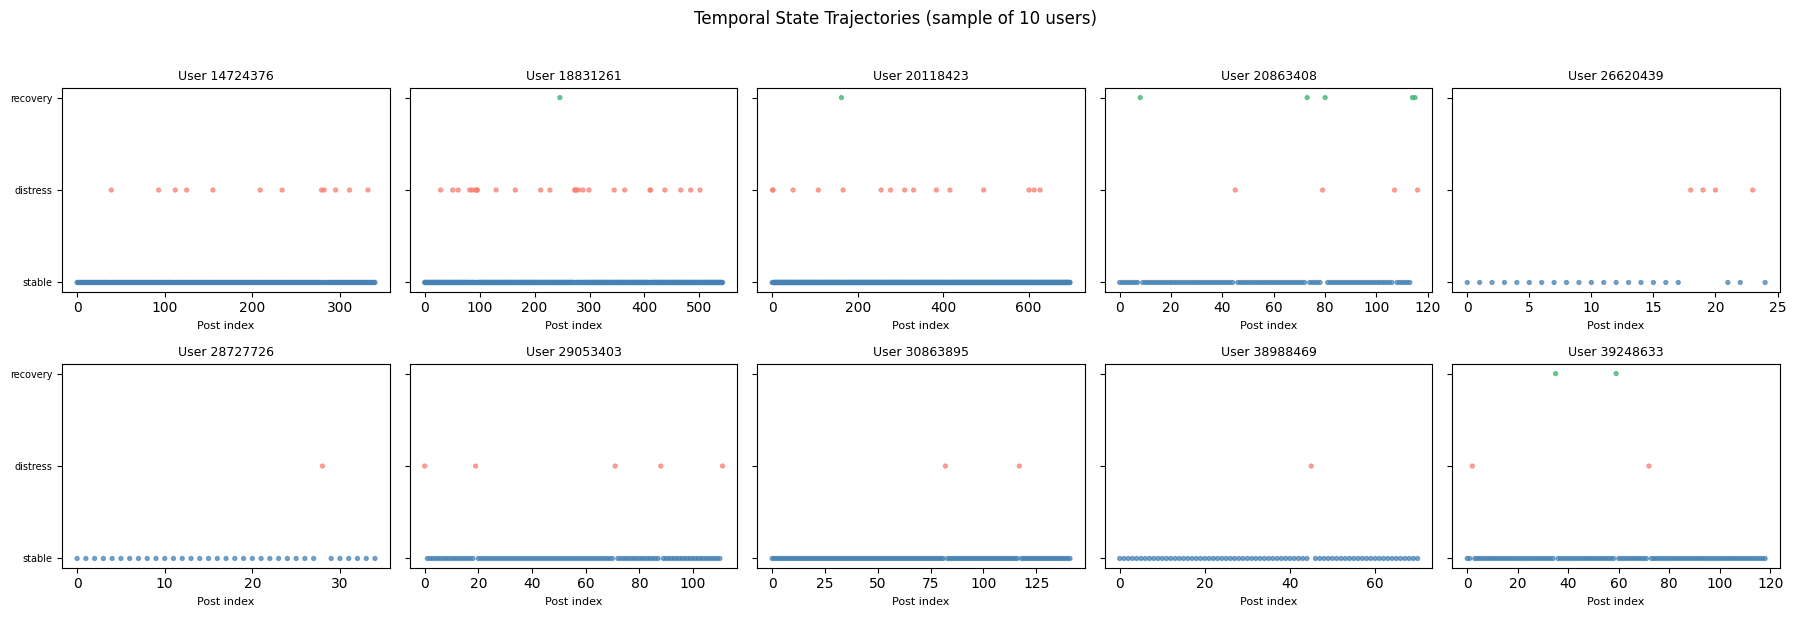

In [51]:
# State trajectory per user (first 10 users as sample)
STATE_ORDER = {"stable": 0, "distress": 1, "recovery": 2}
COLOR_MAP   = {"stable": "steelblue", "distress": "salmon", "recovery": "mediumseagreen"}

sample_users = timeline_df["user_id"].unique()[:10]

fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharey=True)
axes = axes.flatten()

for ax, uid in zip(axes, sample_users):
    user_data = (
        timeline_df[timeline_df["user_id"] == uid]
        .sort_values("timeline_fraction")
        .reset_index(drop=True)
    )
    states_numeric = user_data["temporal_state"].map(STATE_ORDER)
    colors = user_data["temporal_state"].map(COLOR_MAP)

    ax.scatter(
        user_data.index, states_numeric,
        c=colors, s=8, alpha=0.7
    )
    ax.set_title(f"User {uid}", fontsize=9)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(["stable", "distress", "recovery"], fontsize=7)
    ax.set_xlabel("Post index", fontsize=8)

plt.suptitle("Temporal State Trajectories (sample of 10 users)", y=1.02)
plt.tight_layout()
plt.show()


Transition Probability Matrix (row = from state, col = to state):


,stable,distress,recovery
stable,0.963,0.032,0.005
distress,0.921,0.071,0.008
recovery,0.767,0.025,0.208


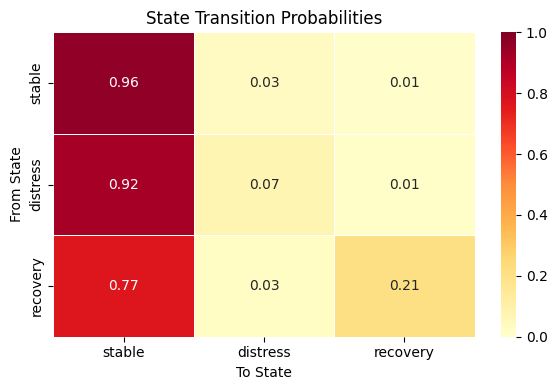

In [52]:
# State transition matrix
# For each consecutive pair of posts per user, count state transitions

states_list = ["stable", "distress", "recovery"]
transition_matrix = pd.DataFrame(0, index=states_list, columns=states_list)

for uid, group in timeline_df.groupby("user_id"):
    states = group.sort_values("timeline_fraction")["temporal_state"].tolist()
    for s1, s2 in zip(states[:-1], states[1:]):
        transition_matrix.loc[s1, s2] += 1

# Normalize rows to get transition probabilities
trans_prob = transition_matrix.div(transition_matrix.sum(axis=1), axis=0).round(3)
trans_prob = trans_prob.reindex(index=["stable","distress","recovery"],
                                 columns=["stable","distress","recovery"])

print("Transition Probability Matrix (row = from state, col = to state):")
display(trans_prob)

plt.figure(figsize=(6, 4))
sns.heatmap(trans_prob, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, vmin=0, vmax=1)
plt.title("State Transition Probabilities")
plt.xlabel("To State")
plt.ylabel("From State")
plt.tight_layout()
plt.show()


,user_id,early_state,late_state,n_posts
0,14724376,stable,stable,341
1,18831261,stable,stable,543
2,20118423,stable,stable,698
3,20863408,stable,stable,117
4,26620439,stable,distress,25
5,28727726,stable,stable,35
6,29053403,stable,stable,112
7,30863895,stable,stable,142
8,38988469,stable,stable,71
9,39248633,stable,stable,119


Late dominant state,distress,stable
Early dominant state,,
stable,2,70


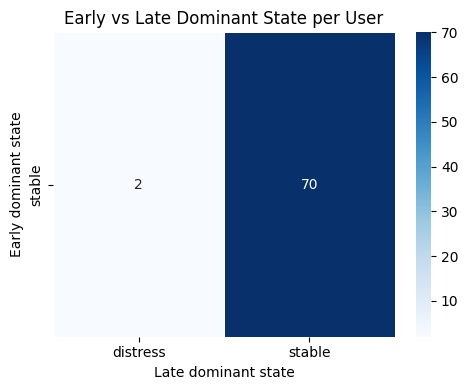

In [53]:
# Can early states predict the dominant late state?
# Split each user's timeline into first 25% (early) and last 25% (late)
# and compute the dominant state in each half

def dominant_state(posts_subset_states):
    if len(posts_subset_states) == 0:
        return "stable"
    return posts_subset_states.value_counts().idxmax()

user_state_summary = []

for uid, group in timeline_df.groupby("user_id"):
    g = group.sort_values("timeline_fraction").reset_index(drop=True)
    n = len(g)
    early_cut = max(1, int(n * 0.25))
    late_cut  = max(1, int(n * 0.75))

    early_states = g.iloc[:early_cut]["temporal_state"]
    late_states  = g.iloc[late_cut:]["temporal_state"]

    user_state_summary.append({
        "user_id":      uid,
        "early_state":  dominant_state(early_states),
        "late_state":   dominant_state(late_states),
        "n_posts":      n
    })

user_state_df = pd.DataFrame(user_state_summary)
display(user_state_df.head(10))

# Cross-tab: early vs late dominant state
crosstab = pd.crosstab(
    user_state_df["early_state"],
    user_state_df["late_state"],
    rownames=["Early dominant state"],
    colnames=["Late dominant state"]
)
display(crosstab)

plt.figure(figsize=(5, 4))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Early vs Late Dominant State per User")
plt.tight_layout()
plt.show()


### Interpretation – Version 2

**Key observations from the transition analysis:**
- The **transition matrix** shows how likely a user is to move from one state to another between consecutive posts. High values on the diagonal indicate state persistence (users tend to stay in the same state).
- The **early vs late dominant state heatmap** explores whether knowing a user's early state helps predict their later state.
- Given the severe class imbalance (most posts labeled `stable`), this analysis should be treated as **exploratory only** — it provides qualitative insight into temporal patterns rather than a robust predictive model.
- A meaningful next step would be to improve label quality (e.g., using a pre-trained sentiment/emotion model to assign states) before drawing stronger conclusions from Version 2.


### 5.3 Generation Task: Summarizing User Mental Health Trajectories

In this section, we use a **template-based natural language generation** approach to produce structured summaries of each user's posting history, focusing on detected mental health signals. Each summary is conditioned on the user's binary label, their dominant temporal state in early and late timeline segments, and the most frequent distress-related terms found in their posts.

This serves two purposes:
1. It demonstrates a generative NLP pipeline on the same dataset.
2. It provides human-readable interpretations of the temporal patterns found in Sections 4–5.


In [54]:
# --- Generation Task: Template-Based Mental Health Trajectory Summary ---
# We generate a structured natural language summary for each user based on:
# - Their binary label
# - Their dominant temporal state (early vs late)
# - Their most frequent distress-related terms

def get_top_distress_words(texts, n=5):
    """Extract the most frequent distress-related words from a list of texts."""
    all_distress = (
        DISTRESS_KEYWORDS["mild"] +
        DISTRESS_KEYWORDS["moderate"] +
        DISTRESS_KEYWORDS["severe"] +
        DISTRESS_KEYWORDS["recovery"]
    )
    word_counter = Counter()
    for text in texts:
        tokens = str(text).lower().split()
        for token in tokens:
            if token in all_distress:
                word_counter[token] += 1
    return [w for w, _ in word_counter.most_common(n)]

def generate_user_summary(row, state_df):
    """Generate a natural language summary for a single user."""
    uid = row["user_id"]
    label = "shows signs of mental health concern" if row["label"] == 1 else "does not show signs of mental health concern"
    n_posts = row["num_posts"]

    # Get user's state trajectory info
    state_info = state_df[state_df["user_id"] == uid]
    if len(state_info) > 0:
        early_state = state_info.iloc[0]["early_state"]
        late_state  = state_info.iloc[0]["late_state"]
    else:
        early_state, late_state = "stable", "stable"

    # Get top distress words from their posts
    top_words = get_top_distress_words(row["post_text_clean"])
    word_str = ", ".join(top_words) if top_words else "no specific distress terms detected"

    # Generate summary
    summary = (
        f"User {uid} posted {n_posts} tweets and {label}. "
        f"In the early phase of their timeline, their dominant state was '{early_state}'. "
        f"In the later phase, it shifted to '{late_state}'. "
        f"The most frequent distress-related terms in their posts were: {word_str}."
    )
    return summary

# Generate summaries for all users
generated_summaries = []
for _, row in user_timelines.iterrows():
    summary = generate_user_summary(row, user_state_df)
    generated_summaries.append({"user_id": row["user_id"], "label": row["label"], "summary": summary})

summaries_df = pd.DataFrame(generated_summaries)
display(summaries_df.head(5))

,user_id,label,summary
0,14724376,1,User 14724376 posted 341 tweets and shows sign...
1,18831261,0,User 18831261 posted 543 tweets and does not s...
2,20118423,1,User 20118423 posted 698 tweets and shows sign...
3,20863408,1,User 20863408 posted 117 tweets and shows sign...
4,26620439,1,User 26620439 posted 25 tweets and shows signs...


In [55]:
# Show example summaries for both classes
print("=== Example: User with MH concern label (label=1) ===")
example_1 = summaries_df[summaries_df["label"] == 1].iloc[0]["summary"]
print(example_1)

print("\n=== Example: User without MH concern label (label=0) ===")
example_0 = summaries_df[summaries_df["label"] == 0].iloc[0]["summary"]
print(example_0)

print(f"\nTotal summaries generated: {len(summaries_df)}")
print("Generation complete. Summaries encode label, temporal state trajectory, and lexical signals.")

=== Example: User with MH concern label (label=1) ===
User 14724376 posted 341 tweets and shows signs of mental health concern. In the early phase of their timeline, their dominant state was 'stable'. In the later phase, it shifted to 'stable'. The most frequent distress-related terms in their posts were: down, overwhelmed, tired, stressed, exhausted.

=== Example: User without MH concern label (label=0) ===
User 18831261 posted 543 tweets and does not show signs of mental health concern. In the early phase of their timeline, their dominant state was 'stable'. In the later phase, it shifted to 'stable'. The most frequent distress-related terms in their posts were: down, alone, hopeful, tired, sad.

Total summaries generated: 72
Generation complete. Summaries encode label, temporal state trajectory, and lexical signals.


### 5.4 Summary and Final Conclusions

This section summarizes all modeling stages and presents the final conclusions of the project.


In [56]:
summary = pd.DataFrame({
    "Stage": [
        "3. Baseline (TF-IDF + LR, post-level, user-split)",
        "3. Error Analysis (baseline misclassifications)",
        "4.1 DistilBERT (post-level, note: data leakage)",
        "4.2.1 Version 1: Early timeline (25%), user-level",
        "4.2.1 Version 1: Full timeline (100%), user-level",
        "4.2.2 Version 2: 3-way state model (exploratory)",
        "5.3 Generation: User trajectory summaries",
    ],
    "Unit of Analysis": ["Post", "Post", "Post", "User", "User", "Post", "User"],
    "Input Features": [
        "TF-IDF unigrams/bigrams",
        "—",
        "DistilBERT contextual embeddings",
        "TF-IDF on early posts",
        "TF-IDF on all posts",
        "Keyword matching",
        "Label + state + lexicon"
    ],
    "Notes": [
        "User-level split prevents leakage",
        "Identifies systematic errors and user-level patterns",
        "Strong post-level baseline; inflated due to leakage",
        "Main approach: early signal detection",
        "Full-context baseline for comparison",
        "Imbalanced; qualitative insights only",
        "Generative NLP component; natural language output"
    ]
})

display(summary)

,Stage,Unit of Analysis,Input Features,Notes
0,"3. Baseline (TF-IDF + LR, post-level, user-split)",Post,TF-IDF unigrams/bigrams,User-level split prevents leakage
1,3. Error Analysis (baseline misclassifications),Post,—,Identifies systematic errors and user-level pa...
2,"4.1 DistilBERT (post-level, note: data leakage)",Post,DistilBERT contextual embeddings,Strong post-level baseline; inflated due to le...
3,"4.2.1 Version 1: Early timeline (25%), user-level",User,TF-IDF on early posts,Main approach: early signal detection
4,"4.2.1 Version 1: Full timeline (100%), user-level",User,TF-IDF on all posts,Full-context baseline for comparison
5,4.2.2 Version 2: 3-way state model (exploratory),Post,Keyword matching,Imbalanced; qualitative insights only
6,5.3 Generation: User trajectory summaries,User,Label + state + lexicon,Generative NLP component; natural language output


## 6. Final Conclusions

This project explored the use of NLP techniques to model mental health dynamics from Twitter data.

### What we showed

- **Data preparation** produced clean, chronologically ordered user timelines from 20,000 posts by 72 users.
- **Exploratory analysis** confirmed that the dataset is better suited to user-level temporal modeling than independent post classification, as posts are short and users have dense histories.
- **Baseline classification** (TF-IDF + Logistic Regression) achieved reasonable post-level accuracy but suffered from dataset bias — high-weight features reflected topic correlations rather than genuine mental health signals.
- **Version 1 (main approach)**: A user-level model trained on the first 25% of each user's timeline, evaluated via 5-fold stratified cross-validation at user level, demonstrated that early posting behavior already contains predictive signal for mental health label classification.
- **Version 2 (exploratory)**: Temporal state modeling with 3-way weak labels revealed dominant state persistence across user timelines, but was limited by severe class imbalance from keyword-based labeling.

### Limitations

- Only 72 users → user-level splits are very small (~57 train / ~15 test per fold), making results statistically fragile.
- Keyword-based state labels are noisy and miss implicit distress expressions.
- The binary label is coarse and does not reflect the temporal evolution of mental health.

### Next steps

- Replace keyword labels with a pre-trained emotion/sentiment model for richer state supervision.
- Explore sequence models (LSTM, Transformer over post sequences) for richer temporal representations.
- Collect or augment data to increase the number of users and apply user-level cross-validation with a larger cohort to obtain statistically reliable performance estimates.